### Imports
PyTorch is standardly imported as `torch`, and its neural network module is imported as `nn`. The `numpy` library is imported for numerical operations, and `matplotlib.pyplot` is imported for plotting and visualizing data. These libraries are essential for building and training neural networks in PyTorch, as well as for handling data manipulation and visualization tasks.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch
import torch.nn as nn
from   IPython.display import HTML

### Equations, Parameters, and Data

The equation being solved is the 2D heat equation, which describes how heat diffuses through a medium over time. The equation is given by:
```math
\frac{\partial u}{\partial t} = \alpha \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
```
Where:
- $u(x, y, t)$ is the temperature distribution as a function of position $(x, y)$ and time $t$.
- $\alpha$ is the thermal diffusivity constant, which determines how quickly heat diffuses through the medium.

This equation is interesting due to the dependency of the solution on both space and time, making it a fundamental example of a parabolic partial differential equation. The ability to solve this equation using Physics-Informed Neural Networks (PINNs) allows for efficient and accurate modeling of complex systems where traditional numerical methods may struggle.

In [18]:
# ----------------------------
# Parameters
# ----------------------------
A        = 25       # Amplitude of the initial Gaussian peaks
alpha    = 0.01     # Diffusion coefficient
temp_min = -2       # Minimum temperature (for the first peak)
temp_max = 2        # Maximum temperature (for the second peak)
tmax     = 5.0      # Simulation time

# `initial_condition` defines the initial temperature distribution as a sum of two Gaussian peaks
def initial_condition(X, Y, A, temp_min, temp_max):
    return (
        temp_min * np.exp(-A*((X-0.3)**2 + (Y-0.3)**2)) +
        temp_max * np.exp(-A*((X-0.7)**2 + (Y-0.7)**2))
    )

# ----------------------------
# Training Data (Initial Condition)
# u(x,y,0) = 
# ----------------------------
N_data = 1000                                   # Number of training data points (points where we have the initial condition)
x_data = torch.rand(N_data,1)                   # Random points in space for training data
y_data = torch.rand(N_data,1)                   # Random points in space for training data
t_data = torch.zeros_like(x_data)               # Initial time t=0

X_data = torch.cat([x_data, y_data, t_data], dim=1)         # Combine x, y, and t for input

u_data = initial_condition(x_data, y_data, A, temp_min, temp_max) # Initial condition u(x,y,0) = 2 peaks at (0.3,0.3) and (0.7,0.7)


# ----------------------------
# Collocation Points
# ----------------------------
N_col = 3000                                    # Number of collocation points (points used to enforce PDE)
x_col = torch.rand(N_col, 1)                    # Random points in space for collocation
y_col = torch.rand(N_col, 1)                    # Random points in space for collocation
t_col = tmax * torch.rand(N_col, 1)             # Random points in time for collocation
X_col = torch.cat([x_col, y_col, t_col], dim=1) # Combine x, y, and t for collocation points

C:\Users\rasno\AppData\Local\Temp\ipykernel_35040\3883617120.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  temp_min * np.exp(-A*((X-0.3)**2 + (Y-0.3)**2)) +
C:\Users\rasno\AppData\Local\Temp\ipykernel_35040\3883617120.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  temp_max * np.exp(-A*((X-0.7)**2 + (Y-0.7)**2))


## Analytical Solution
The analytical solution to the 2D heat equation with the given initial and boundary conditions can be expressed as a Fourier series. The solution is given by:
```math
u(x, y, t) = \sum_{m=1}^{\infty} \sum_{n=1}^{\infty} C_{mn} \sin(m \pi x) \sin(n \pi y) e^{-\alpha \pi^2 (m^2 + n^2) t}
```
Where:
- $C_{mn}$ are the Fourier coefficients determined by the initial condition
- $\alpha$ is the thermal diffusivity
- $m$ and $n$ are the mode numbers in the x and y directions, respectively
The Fourier coefficients $C_{mn}$ can be calculated using the initial temperature distribution $f(x, y)$ as follows:
```math
C_{mn} = 4 \int_0^1 \int_0^1 f(x, y) \sin(m \pi x) \sin(n \pi y) dx dy
```


In [19]:

# ----------------------------
# Analytical Solution (for testing)
# u(x,y,0) = 2 peaks at (0.3,0.3) and (0.7,0.7)
# ----------------------------
# `precompute_grid` creates a grid of points in the spatial domain [0,1]x[0,1] for numerical integration when computing the Fourier coefficients
def precompute_grid(Nx=200, Ny=200):
    x = np.linspace(0, 1, Nx)
    y = np.linspace(0, 1, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    return x, y, X, Y

# `compute_coefficient` calculates the Fourier coefficients for the initial condition by integrating the product of the initial condition and the corresponding basis function (cosine terms) 
# over the spatial domain. The normalization factor is determined based on whether m and n are zero or not, which affects the orthogonality of the basis functions.
def compute_coefficient(m, n, x, y, X, Y, u0):
    phi = np.cos(m * np.pi * X) * np.cos(n * np.pi * Y)
    integrand = u0 * phi

    integral_x = np.trapezoid(integrand, x, axis=0)
    integral   = np.trapezoid(integral_x, y)

    if m == 0 and n == 0:
        norm = 1.0
    elif m == 0 or n == 0:
        norm = 2.0
    else:
        norm = 4.0

    return norm * integral

# `precompute_coefficients` computes the Fourier coefficients for all combinations of m and n up to M and N, respectively, and stores them in a matrix C. 
# This allows for efficient retrieval of the coefficients when calculating the analytical solution at later times.
def precompute_coefficients(M, N, A, temp_min, temp_max, Nx=200, Ny=200):
    x, y, X, Y = precompute_grid(Nx, Ny)
    u0 = initial_condition(X, Y, A, temp_min, temp_max)

    C = np.zeros((M, N))

    for m in range(M):
        for n in range(N):
            C[m, n] = compute_coefficient(m, n, x, y, X, Y, u0)

    return C

# `precompute_phi_cache` precomputes the basis functions (cosine terms) for all combinations of m and n at the grid points defined by X and Y.
def precompute_phi_cache(X, Y, M, N):
    Nx, Ny = X.shape
    phi_cache = np.zeros((M, N, Nx, Ny))

    for m in range(M):
        for n in range(N):
            phi_cache[m, n] = np.cos(m*np.pi*X) * np.cos(n*np.pi*Y)

    return phi_cache

# `analytical_solution` calculates the temperature distribution u(x,y,t) at any given time t using the precomputed Fourier coefficients and basis functions.
def analytical_solution(X, Y, t, alpha, C, phi_cache, M, N):
    u = np.zeros_like(X)

    for m in range(M):
        for n in range(N):
            lam = (m**2 + n**2)
            u += C[m, n] * phi_cache[m, n] * np.exp(-alpha * np.pi**2 * lam * t)

    return u



### Boundary Conditions
The following cell defines both Dirichlet and Neumann boundary conditions for the heat equation. The `dirichlet_bc` enforces fixed temperature values at the boundaries (x=0 and x=1), while the `neumann_bc` enforces zero heat flux at the boundaries, meaning that the spatial derivative of the temperature is zero at those points. These boundary conditions are crucial for ensuring that the solution to the heat equation is physically meaningful and well-posed.

In [20]:
##########################################################################################################################################################
## Dirichlet boundary conditions (u=0 at x=0, x=1, y=0, y=1). Heat and Cold get absorbed at edges. 
##########################################################################################################################################################
## Neumann boundary conditions (du/dn=0 at x=0, x=1, y=0, y=1). No heat flux across the boundaries.
##########################################################################################################################################################
# Variables: N_bc (number of boundary condition points) and t_bc (number of time points for boundary condition sampling)
def sample_boundary_points(N_bc=1000, tmax=1.0):
    t = tmax * torch.rand(N_bc,1)
    
    # --- Create boundary points ---
    x0 = torch.zeros_like(t)                        # Boundary condition at x=0
    x1 = torch.ones_like(t)                         # Boundary condition at x=1
    y0 = torch.zeros_like(t)                        # Boundary condition at y=0
    y1 = torch.ones_like(t)                         # Boundary condition at y=1

    # --- Create random points along the boundaries ---
    x_rand = torch.rand(N_bc,1)                     # Random points in space for boundary conditions (x values for y=0 and y=1)
    y_rand = torch.rand(N_bc,1)                     # Random points in space for boundary conditions (y values for x=0 and x=1)

    # --- Combine boundary points with random points and time to create the full set of boundary condition points ---
    X_left   = torch.cat([x0, y_rand, t], dim=1)    # Combine x=0, random y, and time for left boundary condition points
    X_right  = torch.cat([x1, y_rand, t], dim=1)    # Combine x=1, random y, and time for right boundary condition points
    X_bottom = torch.cat([x_rand, y0, t], dim=1)    # Combine random x, y=0, and time for bottom boundary condition points
    X_top    = torch.cat([x_rand, y1, t], dim=1)    # Combine random x, y=1, and time for top boundary condition points

    return X_left, X_right, X_bottom, X_top


### Defining the Neural Network
Using an objective-oriented approach, we define a class `PINN` that inherits from `nn.Module`. This class will represent our Physics-Informed Neural Network. The constructor (`__init__`) initializes the layers of the neural network, which consist of an input layer, several hidden layers with tanh activation functions, and an output layer. The `forward` method defines how the input data flows through the network to produce the output. This structure allows us to model the solution to the heat equation as a function of both space and time, enabling us to train the network to satisfy the PDE and initial conditions.

In [21]:
# ----------------------------
# Neural Network (3 hidden layers with 64 neurons each)
# ----------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()          # Initialize the neural network architecture. Required for all PyTorch models.
        self.net = nn.Sequential(   # Define a feedforward neural network with...
            nn.Linear(3, 64),       # 3 input features: (x,y,t)
            nn.Tanh(),              # Activation function: Tanh
            nn.Linear(64, 64),      # Hidden layer with 64 neurons
            nn.Tanh(),              # Activation function: Tanh
            nn.Linear(64, 64),      # Hidden layer with 64 neurons
            nn.Tanh(),              # Activation function: Tanh
            nn.Linear(64, 1)        # 1 output feature: u(x,y,t)
        )

    def forward(self, x):           # Define the forward pass of the neural network. This is how the input data flows through the network to produce an output.
        return self.net(x)          # `x` is the input to the network, and `self.net(x)` computes the output by passing `x` through the defined layers.

## Precomputing Fourier Coefficients, Phi Cache, and Analytical Solution
In this section, we precompute the Fourier coefficients $C_{mn}$ for the analytical solution of the heat equation. The function `precompute_coefficients` calculates these coefficients based on the initial temperature distribution and the mode numbers. The function `precompute_phi_cache` precomputes the basis functions (cosine terms) for all combinations of m and n at the grid points. The function `analytical_solution` then uses these coefficients and the precomputed basis functions to compute the temperature distribution at any given time `t`.

In [22]:
# ----------------------------
# Precompute analytical solution components
# ----------------------------
Nx, Ny = 200, 200
x_vis = np.linspace(0,1,Nx)
y_vis = np.linspace(0,1,Ny)
X_np, Y_np = np.meshgrid(x_vis, y_vis, indexing='ij')

M, N = 25, 25   # Increase if needed for accuracy

print("Precomputing Fourier coefficients...")
C = precompute_coefficients(M, N, A, temp_max, Nx, Ny)
print("Done. ")

print("Precomputing spatial modes...")
phi_cache = precompute_phi_cache(X_np, Y_np, M, N)
print("Done. ")

Precomputing Fourier coefficients...
Done. 
Precomputing spatial modes...
Done. 


### Training the PINN
The training process involves defining a loss function that combines the mean squared error of the initial condition and the PDE residual. The optimizer (Adam) is used to minimize this loss by updating the weights of the neural network. During each epoch, we compute the predictions of the network for both the initial condition and the collocation points, calculate the respective losses, and perform backpropagation to update the model parameters. This iterative process continues until the model converges to a solution that satisfies both the initial condition and the PDE.

In [23]:
# ----------------------------
# Training
# ----------------------------
 
epochs    = 15000                                               # Number of training `epochs` (iterations over the entire training dataset)
lr        = 0.001                                               # Learning rate
model     = PINN()                                              # Initialize the PINN model
optimizer = torch.optim.Adam(model.parameters(), lr=lr)         # Use Adam optimizer to train the model with a learning rate of 0.001
M, N = 20, 20
C = precompute_coefficients(M, N, A, temp_min, temp_max)
X_left, X_right, X_bottom, X_top = sample_boundary_points()     # Sample boundary condition points for training (Neumann BCs as implemented)  

# Initialize lists to store loss history for plotting later
loss_total_hist   = []
loss_data_hist    = []
loss_phys_hist    = []
loss_bc_hist      = []

for epoch in range(epochs):
    optimizer.zero_grad()                                       # Clear the gradients from the previous step before computing new gradients for this epoch.   

    ##########################################################################################################################################################
    ## Dirichlet boundary conditions (u=0 at x=0, x=1, y=0, y=1). Heat and Cold get absorbed at edges. 
    ##########################################################################################################################################################
    # u_left   = model(X_left)
    # u_right  = model(X_right)
    # u_bottom = model(X_bottom)
    # u_top    = model(X_top)

    # bc_loss = (
    #     torch.mean(u_left**2) +
    #     torch.mean(u_right**2) +
    #     torch.mean(u_bottom**2) +
    #     torch.mean(u_top**2)
    # )
    ##########################################################################################################################################################
    ##########################################################################################################################################################

    ##########################################################################################################################################################
    ## Neumann boundary conditions (du/dn=0 at x=0, x=1, y=0, y=1). No heat flux across the boundaries.
    ##########################################################################################################################################################
    # --- Enable gradients ---
    X_left   = X_left.clone().detach().requires_grad_(True)     # Create a copy of the left boundary points that requires gradients for automatic differentiation. This allows us to compute derivatives with respect to these points.
    X_right  = X_right.clone().detach().requires_grad_(True)    # "
    X_bottom = X_bottom.clone().detach().requires_grad_(True)   # "
    X_top    = X_top.clone().detach().requires_grad_(True)      # "

    # --- Forward pass ---
    u_left   = model(X_left)                                    # Predict u(x,t) at the left boundary points using the current state of the model. (Used to compute the normal derivative for the Neumann BC.)
    u_right  = model(X_right)                                   # " 
    u_bottom = model(X_bottom)                                  # "
    u_top    = model(X_top)                                     # "

    # --- Compute gradients ---
    grad_left = torch.autograd.grad(                            # Compute the gradients of u with respect to the left boundary points (x,y,t) to get du/dn for the Neumann BC.
        u_left, X_left,                                         # The output at the left boundary points u(x,t) and the input left boundary points (x,y,t)        
        grad_outputs=torch.ones_like(u_left),                   # The gradient of the output with respect to itself, used for chain rule.
        create_graph=True   
    )[0]

    grad_right = torch.autograd.grad(
        u_right, X_right,
        grad_outputs=torch.ones_like(u_right),
        create_graph=True
    )[0]

    grad_bottom = torch.autograd.grad(
        u_bottom, X_bottom,
        grad_outputs=torch.ones_like(u_bottom),
        create_graph=True
    )[0]

    grad_top = torch.autograd.grad(
        u_top, X_top,
        grad_outputs=torch.ones_like(u_top),
        create_graph=True
    )[0]

    # --- Extract normal derivatives ---
    du_dx_left   = grad_left[:,0:1]                               # Extract the derivative with respect to x at the left boundary
    du_dx_right  = grad_right[:,0:1]                              # Extract the derivative with respect to x at the right boundary

    du_dy_bottom = grad_bottom[:,1:2]                             # Extract the derivative with respect to y at the bottom boundary
    du_dy_top    = grad_top[:,1:2]                                # Extract the derivative with respect to y at the top boundary

    # --- Neumann loss ---
    bc_loss = (
        torch.mean(du_dx_left**2) +
        torch.mean(du_dx_right**2) +
        torch.mean(du_dy_bottom**2) +
        torch.mean(du_dy_top**2)
    )
    ##########################################################################################################################################################
    ##########################################################################################################################################################

    # Data loss (initial condition) 
    u_pred_data = model(X_data)                                 # Predict u(x,t) at the training data points (initial condition) using the current state of the model
    data_loss = torch.mean((u_pred_data - u_data)**2)           # Compute the MSE between the predicted values and the true values. (measures crappyness)

    # Physics loss 
    X_col_epoch = X_col.clone().detach().requires_grad_(True)   # Create a copy of the collocation pts that requires gradients for automatic differentiation. This allows us to compute derivatives with respect to these points.
    u = model(X_col_epoch)                                      # Predict u(x,t) at the col pts using the current state of the model. (Used to compute the PDE residual.)

    # ------------ 1 - First derivatives ------------
    grads = torch.autograd.grad(                                # Compute the gradients of u with respect to the collocation points (x,t) to get u_x and u_t for the PDE residual.
        outputs=u,                                              # The output at the collocation points u(x,t)
        inputs=X_col_epoch,                                     # The input collocation points (x,t)
        grad_outputs=torch.ones_like(u),                        # The gradient of the output with respect to itself, used for chain rule.
        create_graph=True                                       # Create a computational graph
    )[0]                                                        # [0] extracts the actual gradients from the returned tuple.

    u_x = grads[:,0:1]                                          # First derivative with respect to x (u_x)
    u_y = grads[:,1:2]                                          # First derivative with respect to y (u_y)
    u_t = grads[:,2:3]                                          # First derivative with respect to t (u_t)  

    # ------------ 2 - Second derivatives (u_xx, u_yy) ------------
    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=X_col_epoch,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:,0:1]     # [0] extracts the actual gradients from the returned tuple and [:,0:1] selects the second derivative with respect to x.

    u_yy = torch.autograd.grad(
        outputs=u_y,
        inputs=X_col_epoch,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0][:,1:2]     # [0] extracts the actual gradients from the returned tuple and [:,1:2] selects the second derivative with respect to y.

    # Heat equation residual
    physics_loss = torch.mean((u_t - alpha * (u_xx + u_yy))**2) # The Laplacian (u_xx + u_yy) represents the spatial second derivatives, and u_t is the time derivative. 

    # Total loss (weighted for biasing)
    lambda_data = 1.0
    lambda_phys = 1.0
    lambda_bc   = 1.0   # Change to 10.0 for Dirichlet BC to enforce them more strongly. Neumann BCs are usually easier to satisfy, so we can keep lambda_bc=1.0 for them.
    loss = (lambda_data * data_loss) + (lambda_phys * physics_loss) + (lambda_bc * bc_loss)

    loss.backward()                                             # Backpropagate the loss to compute gradients of the loss with respect to the model parameters. This is necessary for the optimizer ...
    optimizer.step()                                            # Update the model parameters using the computed gradients. This is where the learning happens.    

    # Store loss history for plotting later
    loss_total_hist.append(loss.item())
    loss_data_hist.append(data_loss.item())
    loss_phys_hist.append(physics_loss.item())
    loss_bc_hist.append(bc_loss.item())

    # Did this in the BC cell above... but its good to check in every now and then
    X_left, X_right, X_bottom, X_top = sample_boundary_points() 

    if (epoch) % 1000 == 0:
        print(f"""
        Epoch {epoch}
        Total:   {loss.item():.4e}
        Data:    {data_loss.item():.4e}
        Physics: {physics_loss.item():.4e}
        BC:      {bc_loss.item():.4e}
        """)


        Epoch 0
        Total:   5.0800e-01
        Data:    5.0650e-01
        Physics: 7.5608e-05
        BC:      1.4279e-03
        

        Epoch 1000
        Total:   2.1734e-02
        Data:    1.7764e-02
        Physics: 1.9818e-03
        BC:      1.9884e-03
        

        Epoch 2000
        Total:   1.1048e-02
        Data:    8.1854e-03
        Physics: 1.3423e-03
        BC:      1.5200e-03
        

        Epoch 3000
        Total:   8.2105e-03
        Data:    4.2574e-03
        Physics: 1.1122e-03
        BC:      2.8408e-03
        

        Epoch 4000
        Total:   4.2092e-03
        Data:    2.5588e-03
        Physics: 9.5541e-04
        BC:      6.9504e-04
        

        Epoch 5000
        Total:   3.2903e-03
        Data:    1.7590e-03
        Physics: 8.1870e-04
        BC:      7.1259e-04
        

        Epoch 6000
        Total:   2.4883e-03
        Data:    1.3184e-03
        Physics: 7.0526e-04
        BC:      4.6465e-04
        

        Epoch 7

## Plot the Training Progress
To visualize the training progress, we plot the total loss, data loss (initial condition), physics loss (PDE residual), and boundary condition loss over epochs. This allows us to see how the model is learning and whether it is converging towards a solution that satisfies the heat equation and the initial conditions. By analyzing these plots, we can gain insights into the training dynamics and identify any potential issues such as overfitting or underfitting.

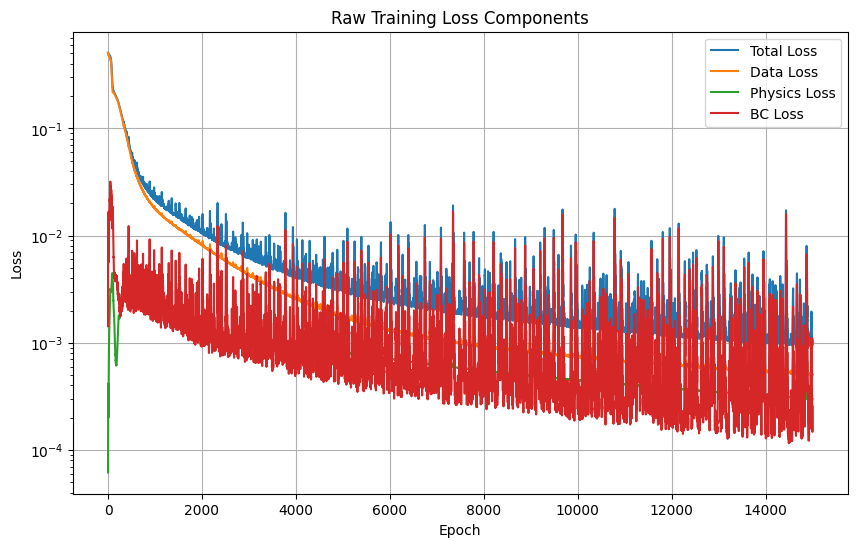

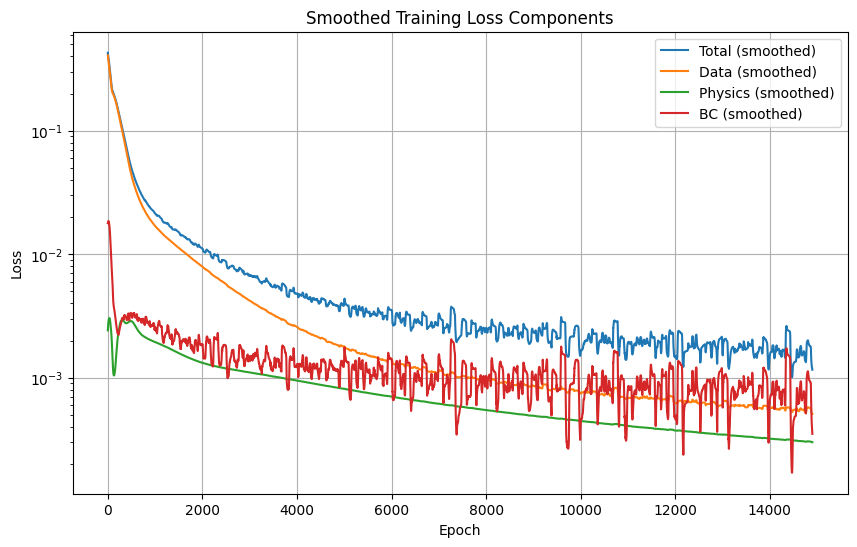

In [24]:
epochs = range(len(loss_total_hist))

#################################
# Raw loss curves
#################################
plt.figure(figsize=(10,6))

plt.plot(epochs, loss_total_hist, label="Total Loss")
plt.plot(epochs, loss_data_hist, label="Data Loss")
plt.plot(epochs, loss_phys_hist, label="Physics Loss")
plt.plot(epochs, loss_bc_hist, label="BC Loss")

plt.yscale('log')  # (Loss spans many orders of magnitude)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Raw Training Loss Components")
plt.legend()
plt.grid(True)

plt.savefig(f"Figures/raw_loss_long_training.png", dpi=300, bbox_inches='tight')
plt.show()

#################################
# Smoothed out loss curves
#################################
def moving_average(y, window=100):
    return np.convolve(y, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,6))

plt.plot(moving_average(loss_total_hist), label="Total (smoothed)")
plt.plot(moving_average(loss_data_hist), label="Data (smoothed)")
plt.plot(moving_average(loss_phys_hist), label="Physics (smoothed)")
plt.plot(moving_average(loss_bc_hist), label="BC (smoothed)")

plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Smoothed Training Loss Components")
plt.legend()
plt.grid(True)

plt.savefig(f"Figures/smoothed_loss_long_training.png", dpi=300, bbox_inches='tight')
plt.show()


### Evaluation and Visualization

After training the model, we evaluate its performance by predicting the temperature distribution at a specific time and comparing it to the analytical solution. We visualize the results using a plot that shows both the predicted and true solutions, allowing us to assess the accuracy of our PINN in solving the heat equation. This step is crucial for validating the effectiveness of our approach and understanding how well the model captures the underlying physics of the problem.

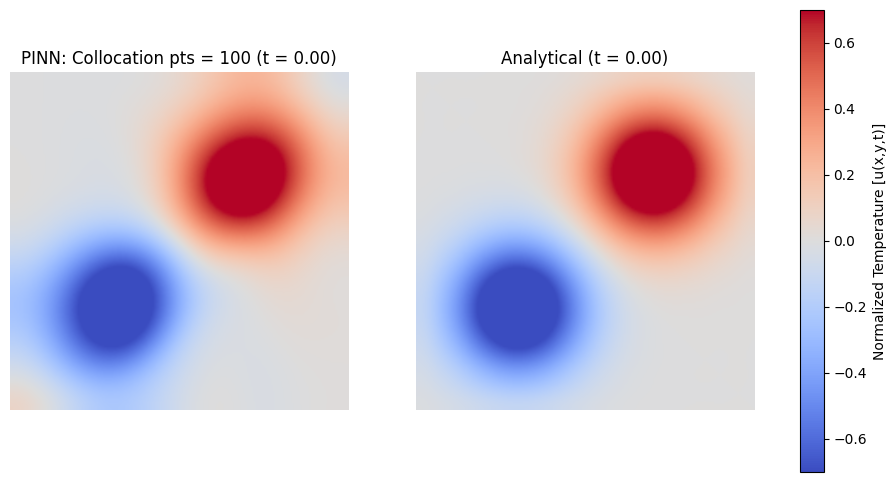

In [16]:
# ----------------------------
# Animation (2D)
# ----------------------------
# Create a grid of (x,y) points for visualization
Nx, Ny = 200, 200                                   # Number of points in x and y directions for visualization
x      = torch.linspace(0,1,Nx)                     # 50 points in space for visualization
y      = torch.linspace(0,1,Ny)                     # 50 points in space for visualization
X, Y   = torch.meshgrid(x,y, indexing='ij')         # Create a grid of (x,y) points for visualization
X_np   = X.numpy()                                  # Convert to numpy for plotting
Y_np   = Y.numpy()                                  # Convert to numpy for plotting

# ----------------------------
# Format the plot
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.axis('off')
ax2.axis('off')
ax1.set_aspect('equal')
ax2.set_aspect('equal')
im1  = ax1.imshow(np.zeros((Nx,Ny)), origin='lower', extent=[0,1,0,1], 
                  cmap='coolwarm', vmin=-0.7, vmax=0.7, interpolation='bilinear')
im2  = ax2.imshow(np.zeros((Nx,Ny)), origin='lower', extent=[0,1,0,1], 
                  cmap='coolwarm', vmin=-0.7, vmax=0.7, interpolation='bilinear')
cbar = plt.colorbar(im1, ax=[ax1, ax2])             # Self explanatory
cbar.set_label("Normalized Temperature [u(x,y,t)]") # Self explanatory

# ----------------------------
# Update function for animation
# ----------------------------
def update(frame):
    # Define the time for the current frame of the animation. This will be used to evaluate the model at different time steps to create the animation effect.
    t_scalar = (frame / 200) * tmax
    t    = torch.full_like(X.reshape(-1,1), t_scalar)  

    # Combine X, Y, and t into a single tensor for input to the model
    X_test = torch.cat([
        X.reshape(-1,1),
        Y.reshape(-1,1),
        t
    ], dim=1)

    # Predict u(x,y,t) at the current time step using the trained model
    u_pred = model(X_test).detach().numpy().reshape(Nx,Ny)
    u_true = analytical_solution(X_np, Y_np, t_scalar, alpha, C, phi_cache, M, N)    # BIG STEP!! Compute the analytical solution at the current time step using the precomputed stuff
    
    im1.set_data(u_pred)
    im2.set_data(u_true)

    # Clear the previous plot and create a new one for the current time step                                  
    ax1.set_title(f"PINN: Collocation pts = {N_col} (t = {t_scalar:.2f})")
    ax2.set_title(f"Analytical (t = {t_scalar:.2f})")
    
    return im1, im2

# ----------------------------
# Call the animation function
# ----------------------------
anim = animation.FuncAnimation(fig, update, frames=200, interval=50)  # Create an animation by repeatedly calling the update function for each frame
anim.save(f"Collocation_pts_{N_col}.mp4", fps=20)

## Another Implemnation of Plotting and Error Analysis 


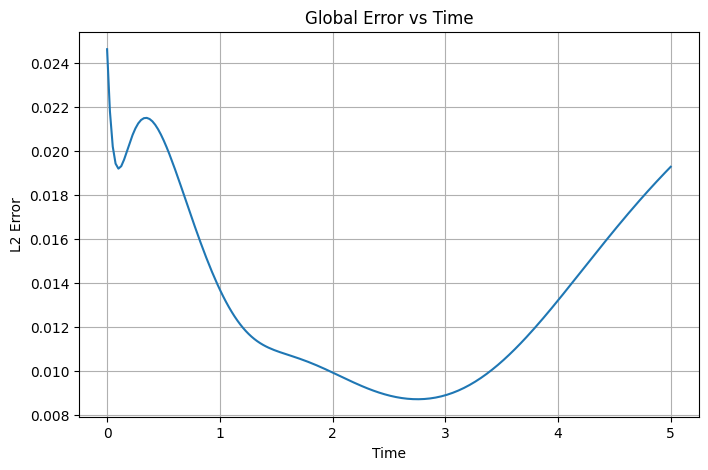

In [27]:
# ----------------------------
# Animation (2D)
# ----------------------------
Nx, Ny = 200, 200                               # Grid resolution (higher = smoother but slower)

# Create 1D spatial grids
x = torch.linspace(0, 1, Nx)                    # x-axis points
y = torch.linspace(0, 1, Ny)                    # y-axis points

# Create 2D meshgrid (X[i,j], Y[i,j])
X, Y = torch.meshgrid(x, y, indexing='ij')

# Convert to NumPy for analytical solution + plotting
X_np = X.numpy()
Y_np = Y.numpy()

# Flatten grid ONCE (used every frame)
X_flat = X.reshape(-1, 1)
Y_flat = Y.reshape(-1, 1)


# ----------------------------
# Format the plot (3 panels)
# ----------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6)) # Create a figure with 3 subplots side by side for the PINN prediction, analytical solution, and error heatmap

# Remove axes and enforce square aspect ratio
for ax in (ax1, ax2, ax3):
    ax.axis('off')
    ax.set_aspect('equal')

# --------- Initialize images  ---------
# PINN prediction
im1 = ax1.imshow(np.zeros((Nx, Ny)),
                 origin='lower',
                 extent=[0,1,0,1],
                 cmap='coolwarm',
                 vmin=-0.7, vmax=0.7)

# Analytical solution
im2 = ax2.imshow(np.zeros((Nx, Ny)),
                 origin='lower',
                 extent=[0,1,0,1],
                 cmap='coolwarm',
                 vmin=-0.7, vmax=0.7)

# Error heatmap
im3 = ax3.imshow(np.zeros((Nx, Ny)),
                 origin='lower',
                 extent=[0,1,0,1],
                 cmap='viridis',
                 vmin=0, vmax=0.2)

# --- Colorbars ---
cbar1 = plt.colorbar(im1, ax=[ax1, ax2])
cbar1.set_label("Temperature u(x,y,t)")

cbar2 = plt.colorbar(im3, ax=ax3)
cbar2.set_label("|Error|")

# ----------------------------
# Animation update function
# ----------------------------
def update(frame):
    """
    Called once per animation frame.
    Computes prediction, analytical solution, and error.
    """
    t_scalar = (frame / 200) * tmax                 # Normalize frame index to physical time
    t = torch.full_like(X_flat, t_scalar)           # Create time tensor matching flattened grid size
    X_test = torch.cat([X_flat, Y_flat, t], dim=1)  # Combine inputs → shape (Nx*Ny, 3)

    # Disable gradient tracking (faster + safer)
    with torch.no_grad():
        u_pred = model(X_test).cpu().numpy().reshape(Nx, Ny)    # Predict using trained PINN

    # Compute analytical solution
    u_true = analytical_solution(X_np, Y_np, t_scalar, alpha, C, phi_cache, M, N)

    # Compute absolute error, modify for visualization (clip outliers)
    error = np.abs(u_pred - u_true)
    im3.set_data(error)
    im3.set_clim(0, np.percentile(error, 99))

    # Update images
    im1.set_data(u_pred)
    im2.set_data(u_true)
    im3.set_data(error)

    # Update titles
    ax1.set_title(f"PINN (t={t_scalar:.2f})")
    ax2.set_title(f"Analytical (t={t_scalar:.2f})")
    ax3.set_title("Dynamic Absolute Error")

    return im1, im2, im3

# ----------------------------
# Create animation
# ----------------------------
anim = animation.FuncAnimation(fig, update, frames=200, interval=50)
anim.save("heat_with_error.mp4", fps=20)
plt.close(fig)          # IMPORTANT: close figure so it doesn't interfere with later plots


# ----------------------------
# Compute L2 error vs time (SEPARATE from animation)
# ----------------------------
time_eval = np.linspace(0, tmax, 200)               # Time samples for evaluation
l2_error_list = []                                  # Store L2 errors


# Loop over time
for t_scalar in time_eval:
    t = torch.full_like(X_flat, t_scalar)           # Create time tensor matching flattened grid size
    X_test = torch.cat([X_flat, Y_flat, t], dim=1)  # Combine inputs

    # Disable gradients
    with torch.no_grad():
        u_pred = model(X_test).cpu().numpy().reshape(Nx, Ny)

    # Compute analytical solution, and then compute L2 error
    u_true = analytical_solution(X_np, Y_np, t_scalar, alpha, C, phi_cache, M, N)   # Analytical solution
    l2_error = np.sqrt(np.mean((u_pred - u_true)**2))   # Compute L2 norm (RMS error over domain)
    l2_error_list.append(l2_error)                      # Store



# ----------------------------
# Plot L2 error vs time
# ----------------------------
plt.figure(figsize=(8,5))
plt.plot(time_eval, l2_error_list)
plt.xlabel("Time")
plt.ylabel("L2 Error")
plt.title("Global Error vs Time")
plt.grid(True)

plt.savefig("l2_error_vs_time.png", dpi=300, bbox_inches='tight')
plt.show()